# Aufgabe 4 — Explorative Datenanalyse (EDA)
**CRISP-DM-Phase: Data Understanding**  
**Projekt:** Basket Trading using Bayesian Optimization  
**Autor:** Nassim Groppe

Schritte: Boxplots (Rendite & Volatilität) → Scatterplots (Feature-Beziehungen) → Korrelationsmatrizen

In [1]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

PROCESSED_DIR = Path.home() / "Desktop/DBU_Data_Analyst_I/data/processed"
OUTPUTS_DIR   = Path.home() / "Desktop/DBU_Data_Analyst_I/outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

prices_df       = pd.read_parquet(PROCESSED_DIR / "prices_cleaned.parquet")
fundamentals_df = pd.read_csv(PROCESSED_DIR / "fundamentals_cleaned.csv")

print(f"Preisdaten:       {prices_df.shape}")
print(f"Fundamentaldaten: {fundamentals_df.shape}")
prices_df.head(3)

Preisdaten:       (150489, 12)
Fundamentaldaten: (89, 12)


,date,ticker,adj_close,close,high,low,open,volume,index_name,daily_return,log_return,volume_zscore
0,2019-07-01,8TRA.DE,NaN,20.949963,21.221632,20.788537,20.946026,1427241.0,MDAX50,NaN,NaN,11.278037
1,2019-07-02,8TRA.DE,NaN,21.300375,21.402744,20.949962,21.036582,447352.0,MDAX50,0.016726,0.016588,2.854364
2,2019-07-03,8TRA.DE,NaN,21.363369,21.536608,21.292500,21.402742,489627.0,MDAX50,0.002957,0.002953,3.217783


## 2. Boxplots — Rendite und Volatilität nach Sektor

/var/folders/b5/m7j2hl2s5g7dxy6swkc1pvhc0000gn/T/ipykernel_63374/4282961433.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(rendite_data, labels=sektoren, showfliers=False, patch_artist=True)
/var/folders/b5/m7j2hl2s5g7dxy6swkc1pvhc0000gn/T/ipykernel_63374/4282961433.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(vola_data, labels=sektoren, showfliers=False, patch_artist=True)


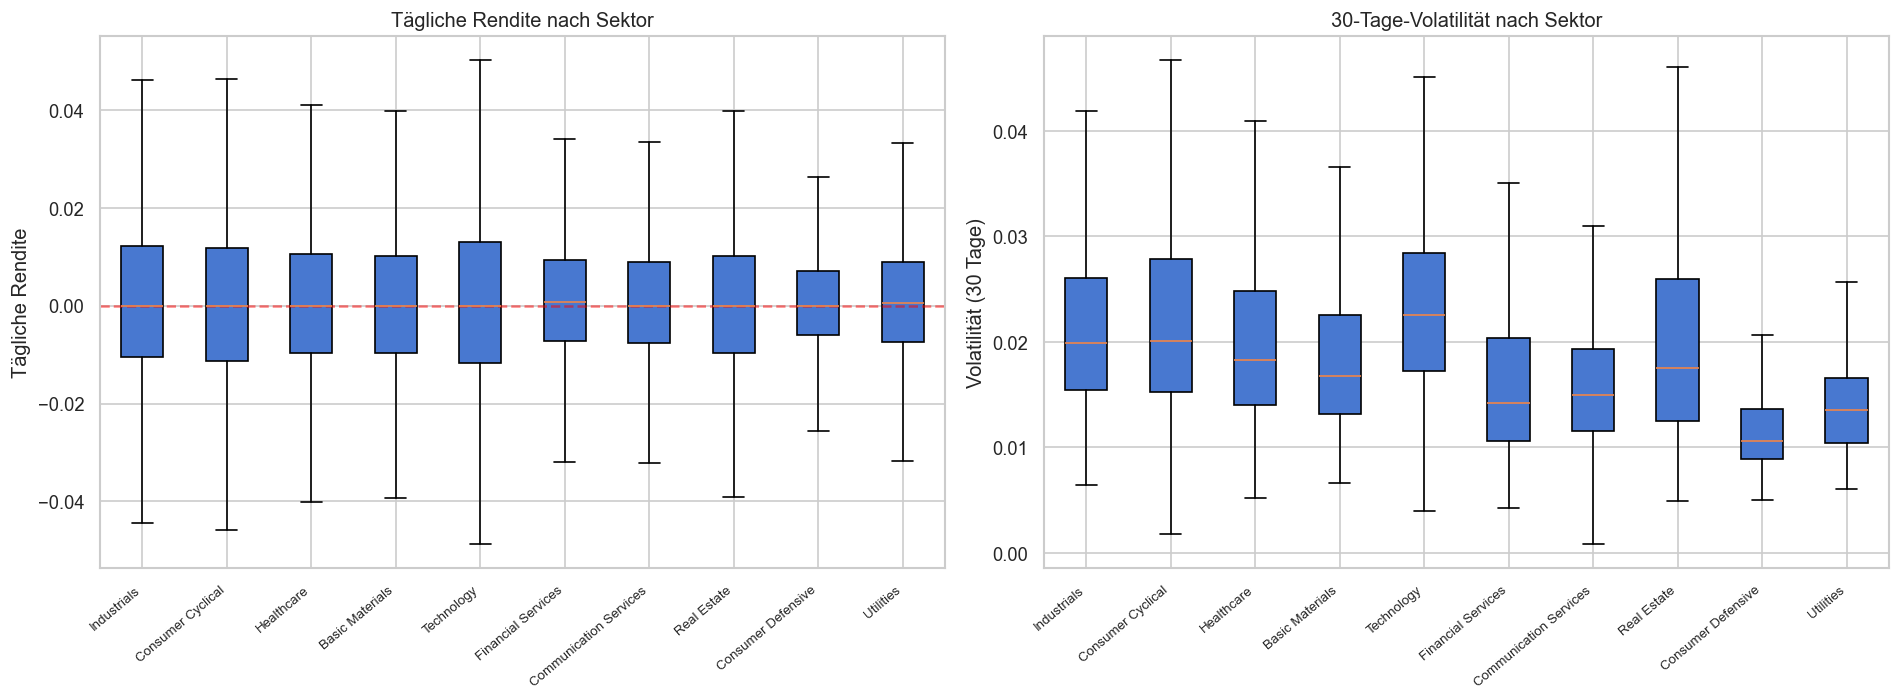

Datenbasis: 86 Ticker in 10 Sektoren


0

In [2]:
# Sektor-Info joinen
merged = prices_df.merge(
    fundamentals_df[['ticker', 'sector']].dropna(),
    on='ticker', how='left'
)
merged = merged[merged['sector'].notna()].copy()
merged = merged.sort_values(['ticker', 'date'])

# 30-Tage-Volatilität
merged['volatility_30d'] = (
    merged.groupby('ticker')['daily_return']
    .transform(lambda s: s.rolling(30, min_periods=10).std())
)

sektoren     = merged['sector'].value_counts().index.tolist()
rendite_data = [merged.loc[merged['sector'] == s, 'daily_return'].dropna() for s in sektoren]
vola_data    = [merged.loc[merged['sector'] == s, 'volatility_30d'].dropna() for s in sektoren]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].boxplot(rendite_data, labels=sektoren, showfliers=False, patch_artist=True)
axes[0].set_xticklabels(sektoren, rotation=40, ha='right', fontsize=8)
axes[0].set_ylabel("Tägliche Rendite")
axes[0].set_title("Tägliche Rendite nach Sektor")
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)

axes[1].boxplot(vola_data, labels=sektoren, showfliers=False, patch_artist=True)
axes[1].set_xticklabels(sektoren, rotation=40, ha='right', fontsize=8)
axes[1].set_ylabel("Volatilität (30 Tage)")
axes[1].set_title("30-Tage-Volatilität nach Sektor")

plt.tight_layout()
plt.show()

print(f"Datenbasis: {merged['ticker'].nunique()} Ticker in {merged['sector'].nunique()} Sektoren")

# Speicher freigeben
del rendite_data, vola_data
gc.collect()

## 3. Scatterplots — Feature-Beziehungen

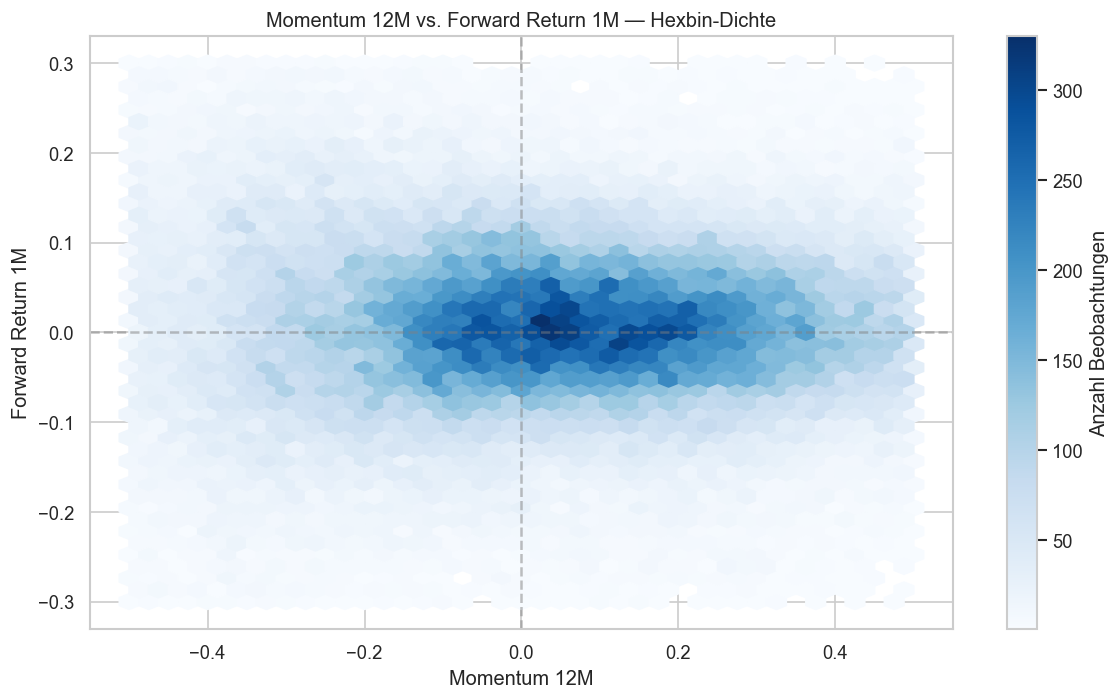

Pearson-Korrelation Momentum vs. Forward Return: -0.0284


5533

In [3]:
# Momentum 12M vs. Forward Return 1M
prices_df_s = prices_df.sort_values(['ticker', 'date']).copy()

prices_df_s['momentum_12m'] = (
    prices_df_s.groupby('ticker')['close']
    .transform(lambda s: s.pct_change(252))
)
prices_df_s['forward_return_1m'] = (
    prices_df_s.groupby('ticker')['close']
    .transform(lambda s: s.shift(-21) / s - 1)
)

scatter_df = prices_df_s[['momentum_12m', 'forward_return_1m']].dropna()
scatter_df = scatter_df[
    scatter_df['momentum_12m'].between(-0.5, 0.5) &
    scatter_df['forward_return_1m'].between(-0.3, 0.3)
]

plt.figure(figsize=(10, 6))
plt.hexbin(scatter_df['momentum_12m'], scatter_df['forward_return_1m'],
           gridsize=40, cmap='Blues', mincnt=1)
plt.colorbar(label='Anzahl Beobachtungen')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("Momentum 12M")
plt.ylabel("Forward Return 1M")
plt.title("Momentum 12M vs. Forward Return 1M — Hexbin-Dichte")
plt.tight_layout()
plt.show()

corr = scatter_df.corr().iloc[0, 1]
print(f"Pearson-Korrelation Momentum vs. Forward Return: {corr:.4f}")

del scatter_df
gc.collect()

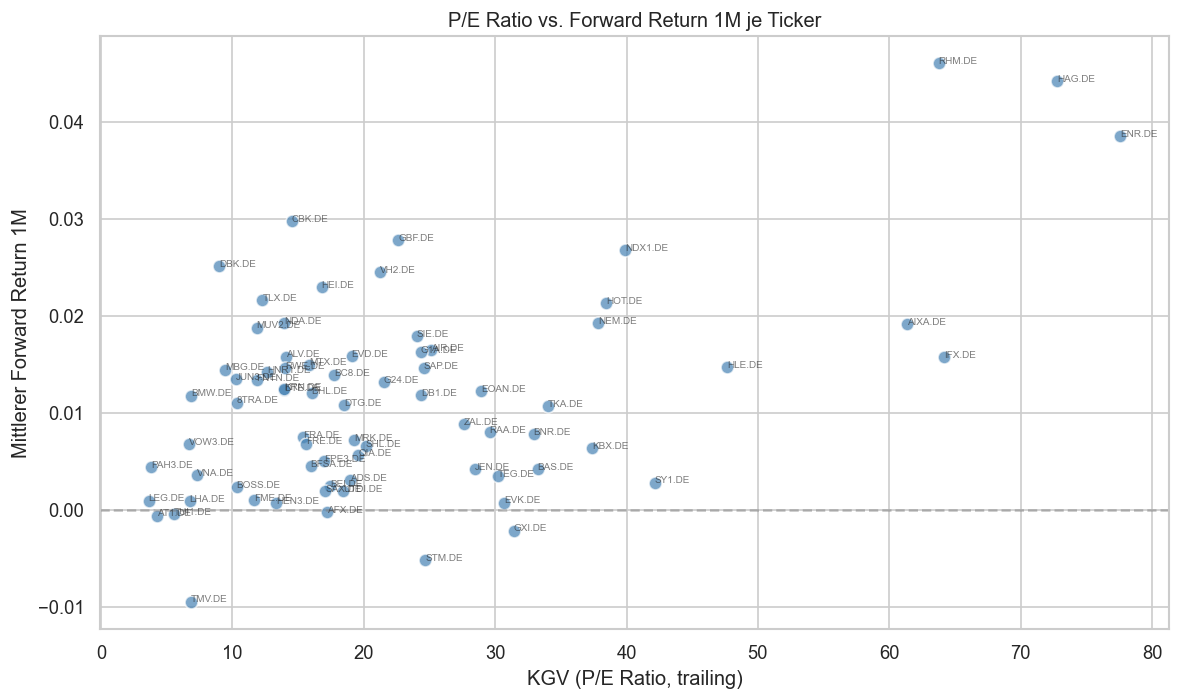

Ticker im Plot: 74
Pearson-Korrelation P/E vs. Forward Return: 0.5185


4175

In [4]:
# P/E Ratio vs. Forward Return 1M
last_fwd = (
    prices_df_s[['ticker', 'forward_return_1m']]
    .dropna()
    .groupby('ticker')['forward_return_1m']
    .mean()
    .reset_index()
)

pe_fwd = last_fwd.merge(
    fundamentals_df[['ticker', 'pe_ratio']].dropna(),
    on='ticker'
)
pe_fwd = pe_fwd[pe_fwd['pe_ratio'].between(0, 80)]

plt.figure(figsize=(10, 6))
plt.scatter(pe_fwd['pe_ratio'], pe_fwd['forward_return_1m'],
            alpha=0.7, color='steelblue', edgecolors='white', s=60)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("KGV (P/E Ratio, trailing)")
plt.ylabel("Mittlerer Forward Return 1M")
plt.title("P/E Ratio vs. Forward Return 1M je Ticker")

for _, row in pe_fwd.iterrows():
    plt.annotate(row['ticker'], (row['pe_ratio'], row['forward_return_1m']),
                 fontsize=6, alpha=0.6)

plt.tight_layout()
plt.show()

corr3 = pe_fwd[['pe_ratio', 'forward_return_1m']].corr().iloc[0, 1]
print(f"Ticker im Plot: {len(pe_fwd)}")
print(f"Pearson-Korrelation P/E vs. Forward Return: {corr3:.4f}")

del last_fwd, pe_fwd
gc.collect()

## 4. Korrelationsmatrizen

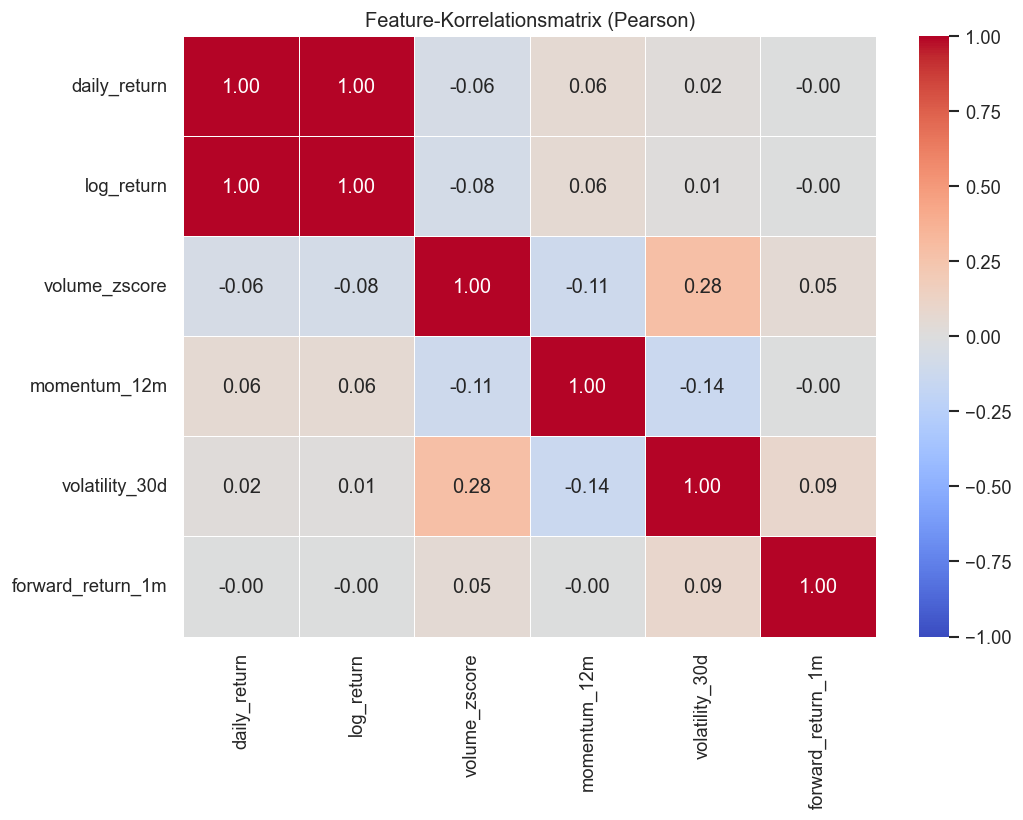

Korrelationsmatrix:
                   daily_return  log_return  volume_zscore  momentum_12m  \
daily_return              1.000       0.999         -0.058         0.056   
log_return                0.999       1.000         -0.078         0.059   
volume_zscore            -0.058      -0.078          1.000        -0.111   
momentum_12m              0.056       0.059         -0.111         1.000   
volatility_30d            0.021       0.008          0.282        -0.137   
forward_return_1m        -0.003      -0.005          0.048        -0.002   

                   volatility_30d  forward_return_1m  
daily_return                0.021             -0.003  
log_return                  0.008             -0.005  
volume_zscore               0.282              0.048  
momentum_12m               -0.137             -0.002  
volatility_30d              1.000              0.093  
forward_return_1m           0.093              1.000  


7051

In [5]:
# Feature-Korrelationen (Multikollinearitätsprüfung)
feature_cols = ['daily_return', 'log_return', 'volume_zscore',
                'momentum_12m', 'volatility_30d', 'forward_return_1m']

# volatility_30d aus merged übernehmen
prices_df_s = prices_df_s.merge(
    merged[['ticker', 'date', 'volatility_30d']],
    on=['ticker', 'date'], how='left'
)

feat_df     = prices_df_s[feature_cols].dropna()
corr_matrix = feat_df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    xticklabels=feature_cols, yticklabels=feature_cols,
    linewidths=0.5
)
plt.title("Feature-Korrelationsmatrix (Pearson)")
plt.tight_layout()
plt.show()

print("Korrelationsmatrix:")
print(corr_matrix.round(3))

del feat_df, corr_matrix
gc.collect()

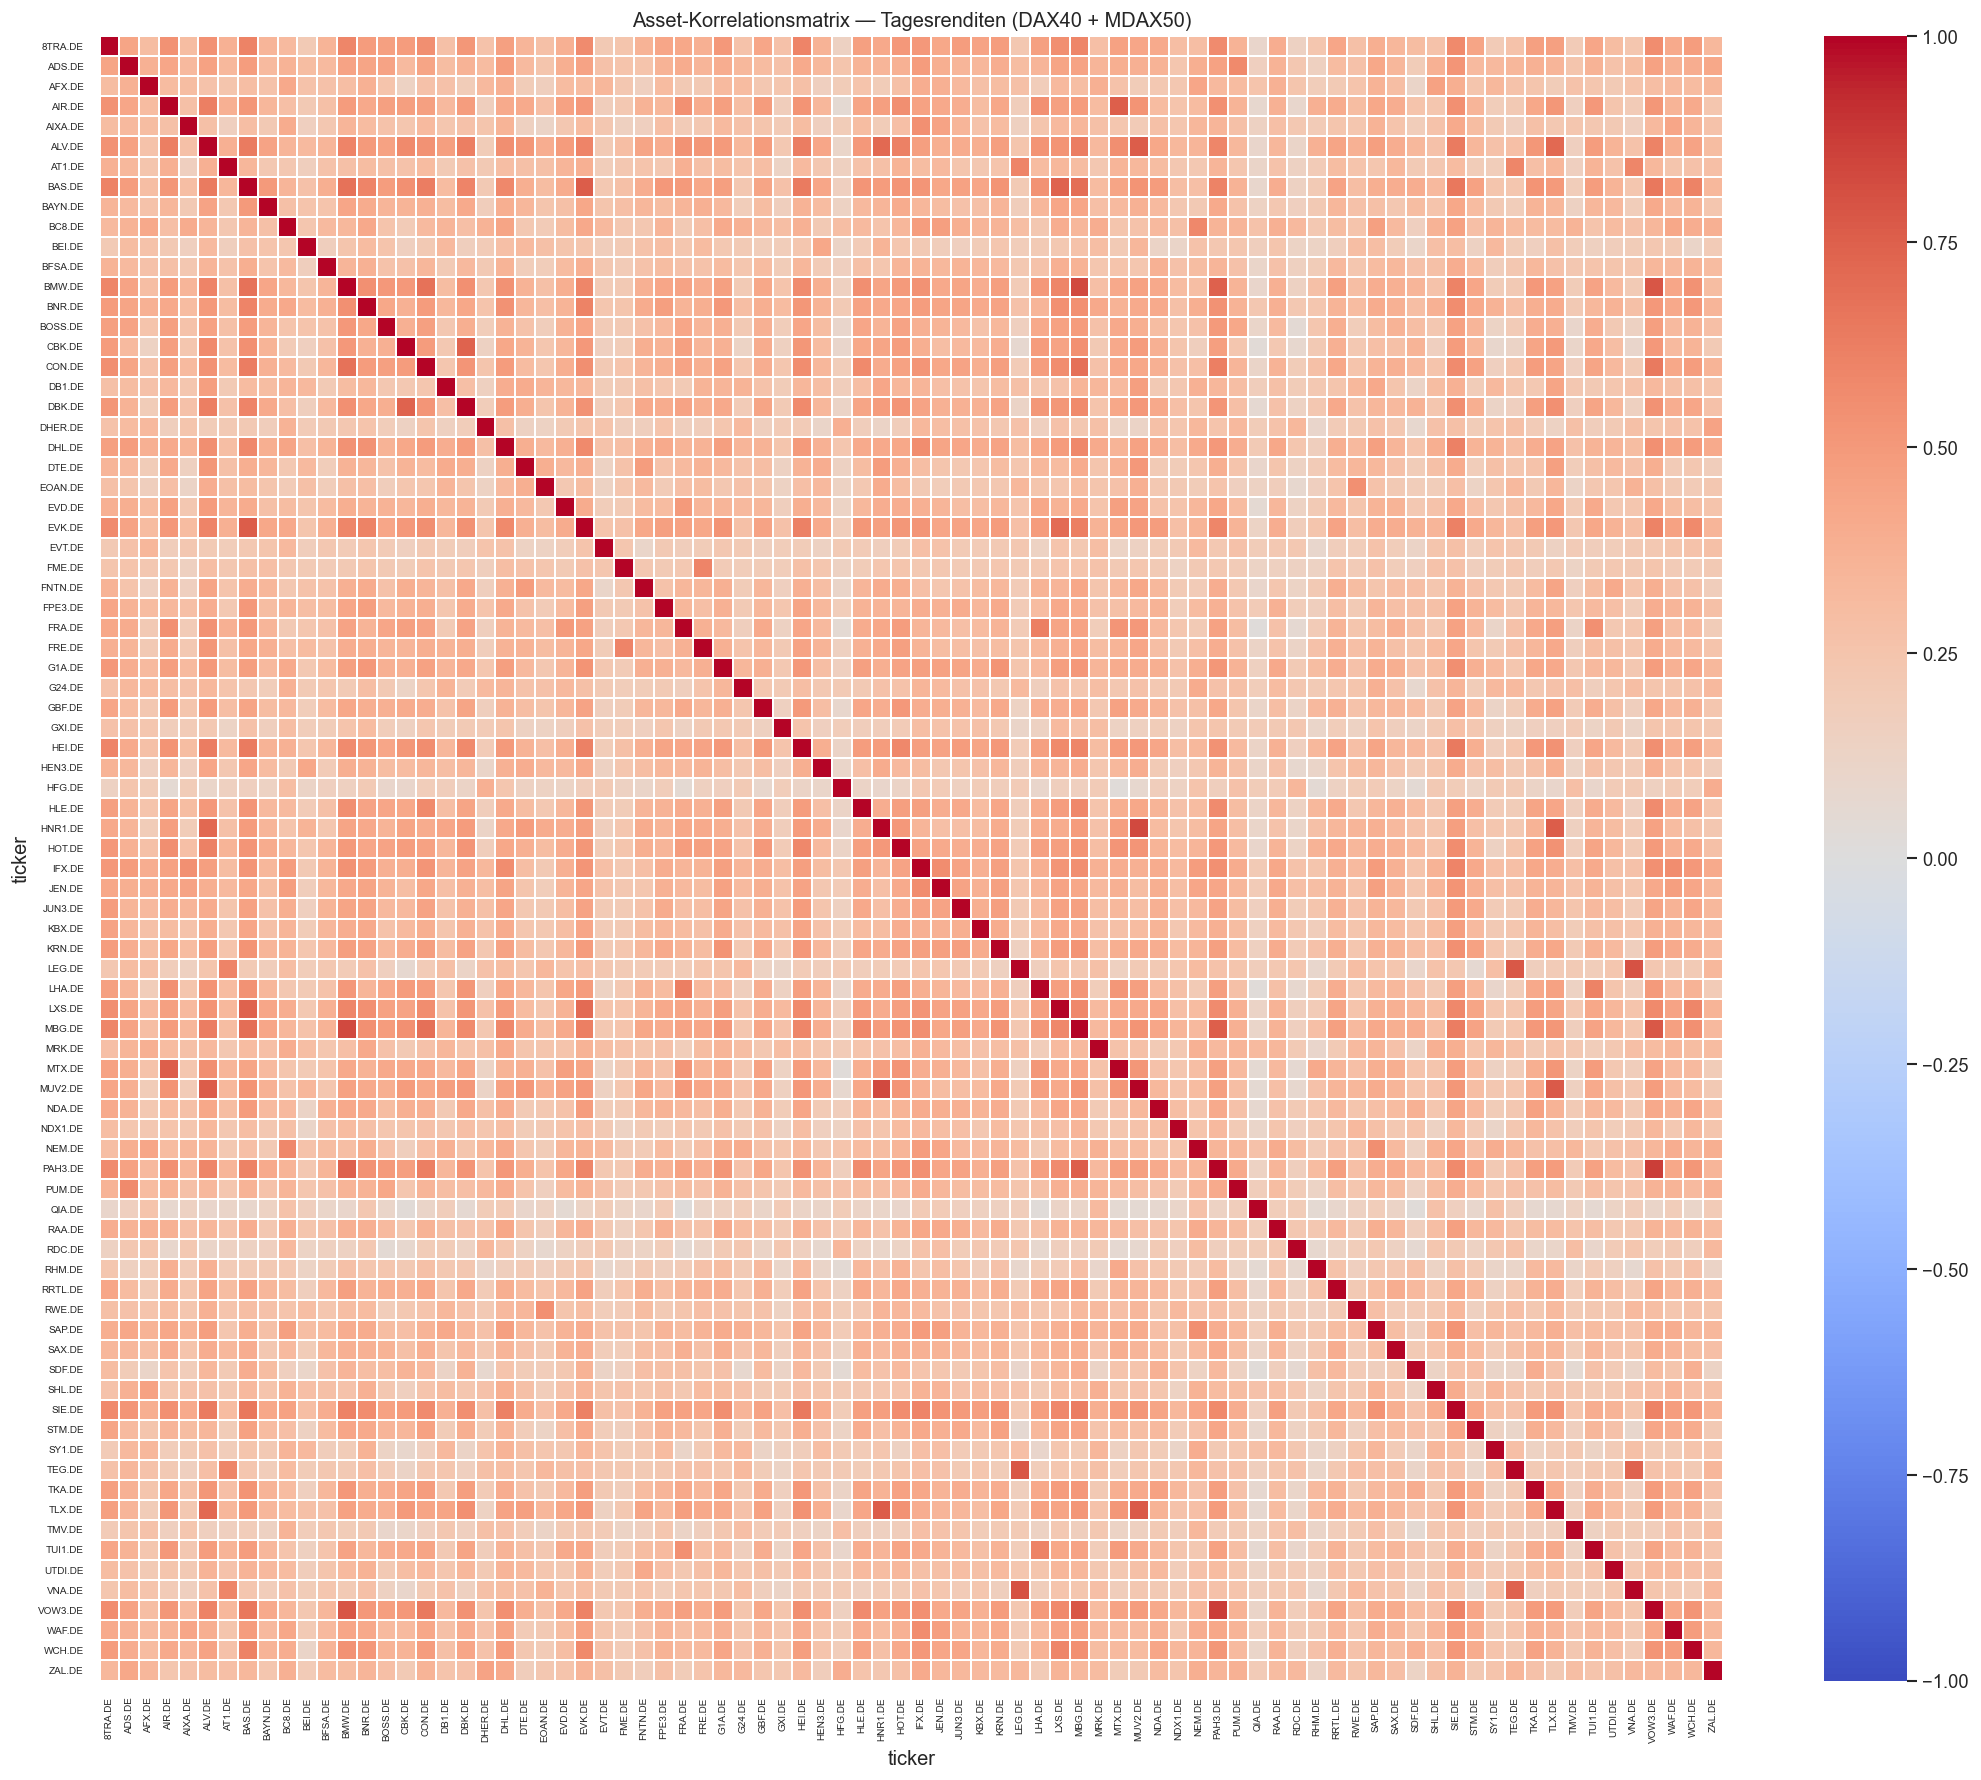

Mittlere Paarkorrelation: 0.3134
(Niedrigerer Wert = bessere Diversifikationsbasis)


19057

In [6]:
# Asset-Korrelationsmatrix (Tagesrenditen — Basis für Diversifikations-Clustering)
price_pivot = prices_df_s.pivot_table(
    index='date', columns='ticker', values='daily_return'
)
price_pivot = price_pivot.dropna(thresh=int(len(price_pivot) * 0.8), axis=1)
asset_corr  = price_pivot.corr()

plt.figure(figsize=(18, 15))
sns.heatmap(
    asset_corr,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    xticklabels=True, yticklabels=True,
    linewidths=0.1, annot=False
)
plt.title("Asset-Korrelationsmatrix — Tagesrenditen (DAX40 + MDAX50)")
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6, rotation=0)
plt.tight_layout()
plt.show()

mean_corr = asset_corr.where(
    ~np.eye(len(asset_corr), dtype=bool)
).stack().mean()
print(f"Mittlere Paarkorrelation: {mean_corr:.4f}")
print(f"(Niedrigerer Wert = bessere Diversifikationsbasis)")

del price_pivot, asset_corr
gc.collect()